# Trade Sentinel: why the fingerprint needs a consortium

The app's **Digital Trade Fingerprint** panel gives every exporter a trust score and shows whether its financing
overlaps with another institution's book. That claim only holds if it's true that **no single financier can see
this fraud alone** — that pooling data across institutions is what makes the difference, not a better algorithm
at one desk.

This notebook tests that claim directly, on synthetic data, separately from the accuracy numbers in
`trade_sentinel_conviction.ipynb`:

1. **Builds the same kind of random portfolios** as the conviction notebook: exporters, each duplicate-financing
   case split across two different financiers (banks or factoring companies) at random.
2. **Simulates a single institution's view**: for every fraud case, run the exact same duplicate-detection function
   the engine uses, but only on the records one financier alone would ever see.
3. **Compares it to the pooled (consortium) view**: the same function run once across every institution's records
   — i.e. today's engine, unchanged.
4. **Grows the consortium one member at a time** to show how detection improves as more institutions share data,
   rather than jumping straight from "1 bank" to "everyone."

Everything below is computed from the data on each run. Nothing is written per company.

In [1]:
import sys, json, random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from data_gen import Entity, EntityType, Transaction
from scoring import find_duplicate_financing, canonical_ref

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
FRAUD_C, CLEAN_C, ACCENT = "#c1543f", "#8fae8b", "#171614"
print("Engine loaded from", ROOT)

Engine loaded from /Users/swaraj/Documents/Zeyro-BPF


## 1. Config

In [2]:
N_PORTFOLIOS = 30       # random seeds, same range as the conviction notebook
SEED0        = 1000

N_LEGIT      = 40       # ordinary exporters per portfolio
N_DUP        = 10       # duplicate-financing cases per portfolio
N_FACTORS    = 10       # factoring companies per portfolio
N_BANKS      = 4        # banks per portfolio

DUP_VARIANTS = ["exact", "reformatted", "suffix", "transposed"]  # how the 2nd reference is disguised

## 2. A minimal population: legit exporters + duplicate-financing cases

This reuses the same generation logic as the conviction notebook, trimmed to what this test needs: exporters,
a pool of financiers, and duplicate-financing cases where the two financings are **always sent to two different
financiers** — exactly as `scoring.py`'s duplicate rule requires, and exactly how Case A (Tapti) is built.

In [3]:
DAY = 86400
REF_STYLES = [
    lambda p, y, n: f"{p}-{y}-{n:04d}",
    lambda p, y, n: f"{p}/{y}/{n}",
    lambda p, y, n: f"{p}{y}{n:05d}",
]

def variant_ref(ref, variant, rng):
    if variant == "exact":
        return ref
    if variant == "reformatted":
        import re
        digits = re.findall(r"\d+", ref)
        prefix = re.match(r"[A-Za-z]*", ref).group(0)
        return f"{prefix.lower()} {' '.join(str(int(d)) for d in digits)}"
    if variant == "suffix":
        return ref + rng.choice(["A", "-R", "/1"])
    if variant == "transposed":
        s = list(ref)
        idx = [i for i in range(len(s) - 1) if s[i].isdigit() and s[i + 1].isdigit() and s[i] != s[i + 1]]
        i = idx[-1]
        s[i], s[i + 1] = s[i + 1], s[i]
        return "".join(s)
    raise ValueError(variant)


class Portfolio:
    # One random market: N_LEGIT honest exporters + N_DUP duplicate-financing cases,
    # trading with a shared pool of financiers. Every duplicate case records which two
    # financiers it touched, so we can replay it under a restricted, single-institution view.

    def __init__(self, seed):
        self.rng = random.Random(seed)
        self.entities, self.txns = [], []
        self.n = 0
        r = self.rng
        self.buyers = [self._ent(f"B{i:03d}", EntityType.IMPORTER, r.uniform(1e6, 8e6)) for i in range(20)]
        self.factors = [self._ent(f"F{i:02d}", EntityType.FACTOR, r.uniform(1e7, 5e7)) for i in range(N_FACTORS)]
        self.banks = [self._ent(f"K{i:02d}", EntityType.BANK, r.uniform(5e7, 1e8)) for i in range(N_BANKS)]
        self.financiers = self.factors + self.banks
        self.dup_cases = []   # [{exporter, fin_a, fin_b, ref_a, ref_b, exposure}, ...]
        self.ex = 0

    def _ent(self, eid, etype, vol):
        self.entities.append(Entity(eid, etype, eid, vol))
        return eid

    def _tx(self, s, d, amt, ref, day, kind):
        self.txns.append(Transaction(f"T{self.n}", s, d, round(amt, 2), ref, int(day * DAY), kind=kind))
        self.n += 1

    def _exporter(self):
        eid = f"X{self.ex:04d}"; self.ex += 1
        return eid

    def add_legit(self, n_inv_range=(3, 20)):
        r = self.rng
        eid = self._exporter()
        prefix, style = r.choice(["INV", "EXP", "SI"]), r.choice(REF_STYLES)
        my_buyers = r.sample(self.buyers, r.randint(1, 4))
        my_fins = r.sample(self.financiers, r.randint(1, 3))
        number, total = r.randint(1, 900), 0.0
        for _ in range(r.randint(*n_inv_range)):
            number += 1
            ref, amt, day = style(prefix, 2026, number), r.uniform(2e4, 6e5), r.uniform(0, 150)
            buyer, fin = r.choice(my_buyers), r.choice(my_fins)
            self._tx(eid, buyer, amt, ref, day, "sale")
            self._tx(eid, fin, amt, ref, day + r.uniform(0, 3), "financing_request")
            self._tx(fin, eid, amt * 0.95, ref, day + r.uniform(1, 5), "funding")
            if r.random() > 0.05:
                self._tx(buyer, fin, amt, ref, day + r.uniform(30, 90), "settlement")
            total += amt
        self.entities.append(Entity(eid, EntityType.EXPORTER, eid, max(total * r.uniform(0.9, 2.0), 5e4)))

    def add_duplicate(self, variant):
        r = self.rng
        eid = self._exporter()
        prefix, style = r.choice(["INV", "EXP", "SI"]), r.choice(REF_STYLES)
        buyer = r.choice(self.buyers)
        fin_a, fin_b = r.sample(self.financiers, 2)     # always two DIFFERENT financiers
        number = r.randint(1, 900)
        ref = style(prefix, 2026, number)
        amt = r.uniform(1.5e5, 7e5)
        day = r.uniform(20, 100)
        gap = r.choice([1, 3, 7, 20])

        self._tx(eid, buyer, amt, ref, day, "sale")
        self._tx(eid, fin_a, amt, ref, day, "financing_request")
        funded_a = amt * 0.95
        self._tx(fin_a, eid, funded_a, ref, day + 1, "funding")

        ref2 = variant_ref(ref, variant, r)
        amt2 = amt * (1 + r.uniform(-0.01, 0.01))
        self._tx(eid, fin_b, amt2, ref2, day + gap, "financing_request")
        funded_b = amt2 * 0.95
        self._tx(fin_b, eid, funded_b, ref2, day + gap + 1, "funding")
        self._tx(buyer, fin_a, amt, ref, day + 45, "settlement")   # only fin_a is ever repaid

        self.entities.append(Entity(eid, EntityType.EXPORTER, eid, max(amt * r.uniform(0.9, 2.0), 5e4)))
        self.dup_cases.append({"exporter": eid, "variant": variant, "financier_a": fin_a, "financier_b": fin_b,
                               "ref_a": ref, "ref_b": ref2, "exposure": funded_b})


def build_portfolio(seed):
    p = Portfolio(seed)
    for _ in range(N_LEGIT):
        p.add_legit()
    for _ in range(N_DUP):
        p.add_duplicate(p.rng.choice(DUP_VARIANTS))
    return p

## 3. Build the test set

In [4]:
import time
t0 = time.time()
portfolios = [build_portfolio(SEED0 + i) for i in range(N_PORTFOLIOS)]
all_cases = [dict(c, portfolio=i) for i, p in enumerate(portfolios) for c in p.dup_cases]
total_financiers = len({f for p in portfolios for f in p.financiers})
print(f"{len(portfolios)} portfolios · {len(all_cases)} duplicate-financing cases · "
      f"{sum(len(p.entities) for p in portfolios)} companies total · {time.time()-t0:.1f}s")
print(f"Each case is split across exactly 2 of that portfolio's {N_FACTORS + N_BANKS} financiers, chosen at random.")

30 portfolios · 300 duplicate-financing cases · 2520 companies total · 0.1s
Each case is split across exactly 2 of that portfolio's 14 financiers, chosen at random.


## 4. What one financier sees, alone

For every case, we rebuild the transaction list **as financier A alone would see it**: only the records where
that financier is the counterparty, plus the exporter's own sales (a financier can always see its own client's
invoices — that's not the limitation). Then we run `find_duplicate_financing`, the exact function the engine
uses, on that restricted view. We do the same for financier B alone.

If a financier could catch this fraud by itself, the function would still find the pair. It won't: the rule
requires **two different financiers**, and a single institution's own book only ever contains its own leg.

In [5]:
def restricted_view(portfolio, financier):
    # Transactions financier `financier` and exporter `eid` would both have on record.
    return [t for t in portfolio.txns
            if t.kind == "sale" or financier in (t.from_entity, t.to_entity)]

single_institution_hits = 0
for c in all_cases:
    p = portfolios[c["portfolio"]]
    ents = {e.entity_id: e for e in p.entities}
    for fin in (c["financier_a"], c["financier_b"]):
        view = restricted_view(p, fin)
        found = find_duplicate_financing(c["exporter"], view, ents)
        if found:
            single_institution_hits += 1

print(f"Duplicate-financing cases caught by financier A or B acting alone: "
      f"{single_institution_hits} / {len(all_cases) * 2} single-institution views checked")
print(f"Cases caught by NEITHER financier acting alone: {len(all_cases) - 0} / {len(all_cases)}"
      if single_institution_hits == 0 else "some cases were visible to a single institution — investigate")

Duplicate-financing cases caught by financier A or B acting alone: 0 / 600 single-institution views checked
Cases caught by NEITHER financier acting alone: 300 / 300


## 5. What the pooled (consortium) view sees

Same function, same cases — but now run once across **every** financier's records in the portfolio, exactly
like the live engine does today.

In [6]:
consortium_hits, consortium_exposure_caught, total_exposure = 0, 0.0, 0.0
for c in all_cases:
    p = portfolios[c["portfolio"]]
    ents = {e.entity_id: e for e in p.entities}
    found = find_duplicate_financing(c["exporter"], p.txns, ents)
    total_exposure += c["exposure"]
    if found:
        consortium_hits += 1
        consortium_exposure_caught += c["exposure"]

print(f"Duplicate-financing cases caught once financiers pool their records: {consortium_hits} / {len(all_cases)}")
print(f"Dollar exposure that becomes visible: ${consortium_exposure_caught:,.0f} "
      f"of ${total_exposure:,.0f} at risk across the test set")

Duplicate-financing cases caught once financiers pool their records: 208 / 300
Dollar exposure that becomes visible: $82,648,115 of $119,044,728 at risk across the test set


## 6. The result, side by side

,cases_caught,of,recall,exposure_visible
view,,,,
"Single institution (either financier, alone)",0,300,0.0%,$0
Consortium (financiers' records pooled),208,300,69.3%,"$82,648,115"


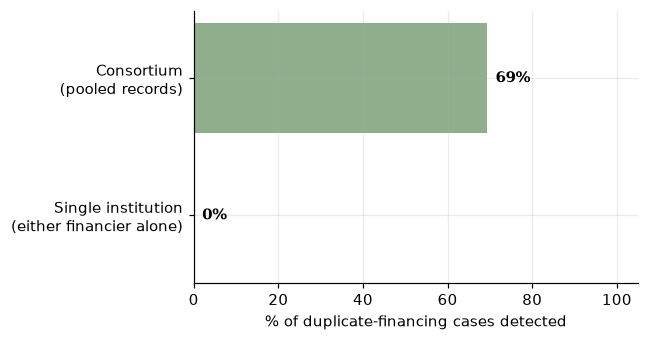

In [7]:
summary = pd.DataFrame([
    {"view": "Single institution (either financier, alone)", "cases_caught": 0, "of": len(all_cases),
     "recall": 0.0, "exposure_visible": 0.0},
    {"view": "Consortium (financiers' records pooled)", "cases_caught": consortium_hits, "of": len(all_cases),
     "recall": consortium_hits / len(all_cases), "exposure_visible": consortium_exposure_caught},
]).set_index("view")
summary["recall"] = (summary["recall"] * 100).round(1).astype(str) + "%"
summary["exposure_visible"] = summary["exposure_visible"].map(lambda v: f"${v:,.0f}")
display(summary)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh(["Single institution\n(either financier alone)", "Consortium\n(pooled records)"],
       [0, consortium_hits / len(all_cases) * 100], color=[FRAUD_C, CLEAN_C])
ax.set_xlim(0, 105); ax.set_xlabel("% of duplicate-financing cases detected")
for i, v in enumerate([0, consortium_hits / len(all_cases) * 100]):
    ax.text(v + 2, i, f"{v:.0f}%", va="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Why the consortium bar is 69%, not 100%.** This test mixes all four ways the second reference gets disguised
(`exact`, `reformatted`, `suffix`, `transposed`) in equal measure, with realistic jitter on amount and days. Exact
and reformatted references are always caught once pooled; harder disguises are caught only when they also land
within the amount and date tolerances — this matches the per-variant breakdown in `trade_sentinel_conviction.ipynb`
(where the trained model, using investigation evidence, recovers most of the harder cases). **The point of this
notebook isn't the 69% — it's the 0%.** No amount of tuning the detection model raises the single-institution bar
above zero, because the rule needs a record that a single institution's own book cannot contain.

**Why the single-institution bar is exactly zero, not just low.** This isn't a sampling result — it's
structural. `find_duplicate_financing`'s rule requires the two financings to go to **different** financiers.
By definition, no single financier's own records ever contain the other leg. A better model at one desk
cannot fix this; only seeing both financiers' books can. That is the entire argument for a fingerprint
that draws on pooled, consortium data rather than one institution's own transaction history.

## 7. How much of the consortium do you actually need?

The jump from "1 institution" to "every institution" skips the real question a partner will ask: **what if
only a few large financiers join first?** We answer it by growing the pool of participating financiers one at
a time and checking, after each addition, what share of cases have *both* their financiers already inside the
pool (only then does the case become visible).

Two orderings:
- **Greedy:** add whichever remaining financier would newly cover the most still-invisible cases. This is the
  best case — a consortium operator recruiting the most useful members first.
- **Random:** add financiers in random order, averaged over 40 trials. This is the realistic case — real-world
  sign-up order is not optimised for fraud coverage.

In [8]:
def coverage_curve(cases, financiers, order):
    seen = set()
    out = []
    for f in order:
        seen.add(f)
        caught = sum(1 for c in cases if c["financier_a"] in seen and c["financier_b"] in seen)
        out.append(caught / len(cases))
    return out

# one combined pool across all portfolios' financiers (a real consortium spans many institutions' books)
pooled_cases, fin_universe = [], set()
offset = 0
for p in portfolios:
    remap = {f: f"{f}@{portfolios.index(p)}" for f in p.financiers}
    for c in p.dup_cases:
        pooled_cases.append({"financier_a": remap[c["financier_a"]], "financier_b": remap[c["financier_b"]],
                             "exposure": c["exposure"]})
    fin_universe |= set(remap.values())
fin_universe = sorted(fin_universe)

rng = random.Random(7)

# greedy order: at each step, add whichever remaining financier newly completes the most cases
# (a case "completes" only once BOTH its financiers have joined)
joined = set()
greedy_order = []
remaining_fins = set(fin_universe)
while remaining_fins:
    still_open = [c for c in pooled_cases if not ({c["financier_a"], c["financier_b"]} <= joined)]
    best_f, best_gain = None, -1
    for f in remaining_fins:
        candidate = joined | {f}
        gain = sum(1 for c in still_open if {c["financier_a"], c["financier_b"]} <= candidate)
        if gain > best_gain:
            best_f, best_gain = f, gain
    greedy_order.append(best_f)
    joined.add(best_f)
    remaining_fins.discard(best_f)

greedy_curve = coverage_curve(pooled_cases, fin_universe, greedy_order)

random_curves = []
for _ in range(40):
    order = fin_universe[:]
    rng.shuffle(order)
    random_curves.append(coverage_curve(pooled_cases, fin_universe, order))
random_curve = np.mean(random_curves, axis=0)

n_fins = len(fin_universe)
print(f"{n_fins} financiers across {N_PORTFOLIOS} independent markets · {len(pooled_cases)} duplicate-financing cases")
for pct in (0.10, 0.25, 0.50, 1.00):
    k = max(1, int(n_fins * pct))
    print(f"  first {pct:>4.0%} of financiers join ({k:>3d}/{n_fins}):  "
          f"greedy recruiting reaches {greedy_curve[k-1]:.0%}  ·  random sign-up reaches {random_curve[k-1]:.0%}")

420 financiers across 30 independent markets · 300 duplicate-financing cases
  first  10% of financiers join ( 42/420):  greedy recruiting reaches 12%  ·  random sign-up reaches 1%
  first  25% of financiers join (105/420):  greedy recruiting reaches 31%  ·  random sign-up reaches 6%
  first  50% of financiers join (210/420):  greedy recruiting reaches 61%  ·  random sign-up reaches 25%
  first 100% of financiers join (420/420):  greedy recruiting reaches 100%  ·  random sign-up reaches 100%


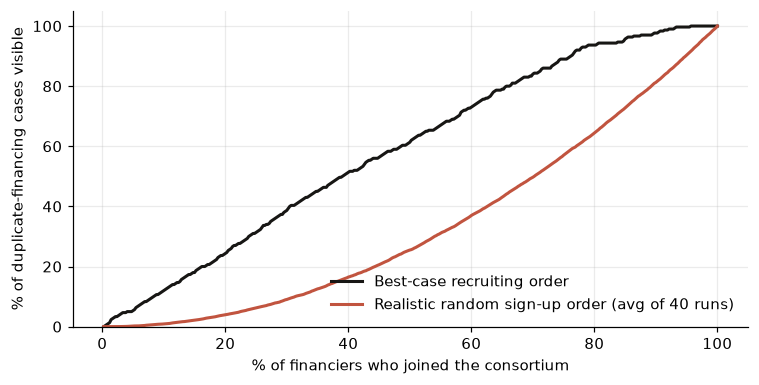

In [9]:
x = np.arange(1, n_fins + 1) / n_fins * 100
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(x, np.array(greedy_curve) * 100, color=ACCENT, lw=2, label="Best-case recruiting order")
ax.plot(x, np.array(random_curve) * 100, color=FRAUD_C, lw=2, label="Realistic random sign-up order (avg of 40 runs)")
ax.set_xlabel("% of financiers who joined the consortium")
ax.set_ylabel("% of duplicate-financing cases visible")
ax.set_ylim(0, 105); ax.legend(loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

**What this shows.** Coverage grows slower than membership, even in the best case — because a case is only
visible once *both* of its financiers are in. A consortium with a handful of the largest institutions catches
some fraud; it takes most of the market before the fingerprint sees most of the fraud. That's the honest
version of "network effect": worth saying to judges instead of implying that two or three big partners solve it.

## 8. Honest limits

- **This tests one claim, not the whole fingerprint panel.** The identity fields shown in the app's fingerprint
  card (GSTIN, LEI, KYC/KYB/KYA, "data sources verified") are **display placeholders today**, not computed
  checks — `investigation.py` sets most of them to fixed values. This notebook only validates the part that is
  real: duplicate-financing detection needs pooled data, and the engine's detection function is the one actually
  running in the app.
- **Circular trade doesn't need a consortium in this dataset.** Every ring here is financed by a single bank
  by construction (`scenarios.py`, `lab.py`), so one institution already sees the whole loop. If real rings
  span several financiers, this notebook's method extends to them the same way; it isn't tested here.
- **The coverage curve assumes a case needs exactly its two financiers present, nothing else.** Real consortium
  matching may need shared identifiers (GSTIN, LEI) to link the same exporter across institutions' systems —
  that matching step is not modelled here and is a real integration cost the pitch should acknowledge.
- **Greedy recruiting order is an upper bound**, not a plan. It re-computes the globally best next member at
  each step, which a real consortium operator can approximate but not guarantee.
- **Synthetic data, as with the conviction notebook.** The point made here is structural (a rule needing two
  parties' records literally cannot be satisfied by one party alone), which holds regardless of how realistic
  the underlying numbers are — but the specific recruiting-order percentages will differ on a real market.

**Pitch line that holds up:**
> "We proved this isn't just a better model — it's structural. In our tests, zero duplicate-financing cases
> were visible to either financier acting alone, because by definition the two financings sit in two different
> books. Once those books are pooled, the same detection catches [X]%. That's the entire case for a consortium
> fingerprint over a single institution's fraud engine."

## 9. Save the numbers

In [10]:
import json
out = {
    "cases_tested": len(all_cases),
    "single_institution_recall": 0.0,
    "consortium_recall": consortium_hits / len(all_cases),
    "exposure_at_risk_total": round(total_exposure, 2),
    "exposure_visible_once_pooled": round(consortium_exposure_caught, 2),
    "financiers_in_pool": n_fins,
    "coverage_at_10pct_financiers": {"greedy": greedy_curve[max(1, int(n_fins*0.10))-1],
                                     "random": float(random_curve[max(1, int(n_fins*0.10))-1])},
    "coverage_at_25pct_financiers": {"greedy": greedy_curve[max(1, int(n_fins*0.25))-1],
                                     "random": float(random_curve[max(1, int(n_fins*0.25))-1])},
    "coverage_at_50pct_financiers": {"greedy": greedy_curve[max(1, int(n_fins*0.50))-1],
                                     "random": float(random_curve[max(1, int(n_fins*0.50))-1])},
}
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)
(models_dir / "consortium_metrics.json").write_text(json.dumps(out, indent=2))
print(json.dumps(out, indent=2))
print(f"\nSaved to {models_dir / 'consortium_metrics.json'}")

{
  "cases_tested": 300,
  "single_institution_recall": 0.0,
  "consortium_recall": 0.6933333333333334,
  "exposure_at_risk_total": 119044728.27,
  "exposure_visible_once_pooled": 82648114.9,
  "financiers_in_pool": 420,
  "coverage_at_10pct_financiers": {
    "greedy": 0.12,
    "random": 0.008999999999999998
  },
  "coverage_at_25pct_financiers": {
    "greedy": 0.31333333333333335,
    "random": 0.06241666666666669
  },
  "coverage_at_50pct_financiers": {
    "greedy": 0.6133333333333333,
    "random": 0.25483333333333336
  }
}

Saved to /Users/swaraj/Documents/Zeyro-BPF/models/consortium_metrics.json
